In [3]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib', '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/tsne', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [12]:
import os
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import my_util
from sklearn.manifold import TSNE
import time

In [9]:
MODE = 'all_features'

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

In [10]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [36]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [37]:
# Convert to Numpy
all_features_np = all_features.to_numpy()
all_features_np

array([[0, 'XLOC_000001', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [1, 'XLOC_000003', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [2, 'XLOC_000006', array([0., 0., 0., ..., 0., 0., 0.]),
        0.0888452],
       ...,
       [22151, 'XLOC_030014', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [22152, 'XLOC_030017', array([0., 0., 0., ..., 0., 0., 0.]), 0.0],
       [22153, 'XLOC_030018', array([0., 0., 0., ..., 0., 0., 0.]), 0.0]],
      dtype=object)

In [38]:
# Prepare the data
data = all_features_np[:, 2]
print(data)
print(data.shape)

[array([0., 0., 0., ..., 0., 0., 0.]) array([0., 0., 0., ..., 0., 0., 0.])
 array([0., 0., 0., ..., 0., 0., 0.]) ...
 array([0., 0., 0., ..., 0., 0., 0.]) array([0., 0., 0., ..., 0., 0., 0.])
 array([0., 0., 0., ..., 0., 0., 0.])]
(22154,)


In [40]:
flattened_data = np.vstack(data)
print(flattened_data)
print(flattened_data.shape)

[[0 0 0 ... 1 0 0]
 [0 0 0 ... 1 1 0]
 [1 1 0 ... 0 1 0]
 ...
 [0 1 0 ... 1 1 0]
 [1 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]
(1000, 20000)


In [41]:
# Apply t-SNE
print("Starting t-SNE...")
start_time = time.time()

Starting t-SNE...


In [42]:
tsne = TSNE(n_components=2, 
            perplexity=30,  # Try values between 5-50
            n_iter=1000, 
            metric='jaccard',  # Jaccard distance is often good for binary data
            random_state=42)

In [43]:
data_tsne = tsne.fit_transform(data)

/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [44]:
print(f"t-SNE completed in {time.time() - start_time:.2f} seconds")

t-SNE completed in 25.19 seconds


In [45]:
print(data_tsne)
print(data_tsne.shape)

[[-10.76418     5.484785 ]
 [ -6.929998    5.132673 ]
 [  8.945162   -4.4371696]
 ...
 [-16.083023   -7.806223 ]
 [ -5.68508     0.7715905]
 [-11.337021   -3.5991714]]
(1000, 2)


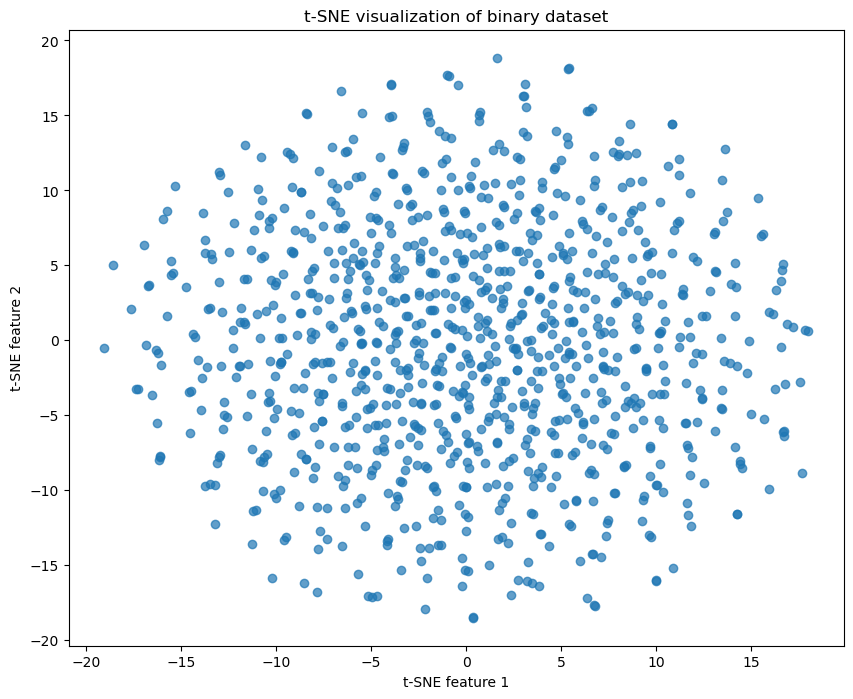

In [46]:
# 3. Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(data_tsne[:, 0], data_tsne[:, 1], alpha=0.7)
plt.title('t-SNE visualization of binary dataset')
plt.xlabel('t-SNE feature 1')
plt.ylabel('t-SNE feature 2')
plt.show()